In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from catboost import CatBoostRegressor

print("Import Successful")

Import Successful


In [4]:
df = pd.read_csv("../data/raw/kc_house_data.csv")

print(f"Dataset shape: {df.shape}")

df.head(5)

Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (21613, 21)

Columns:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [8]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [9]:
df["price"].describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

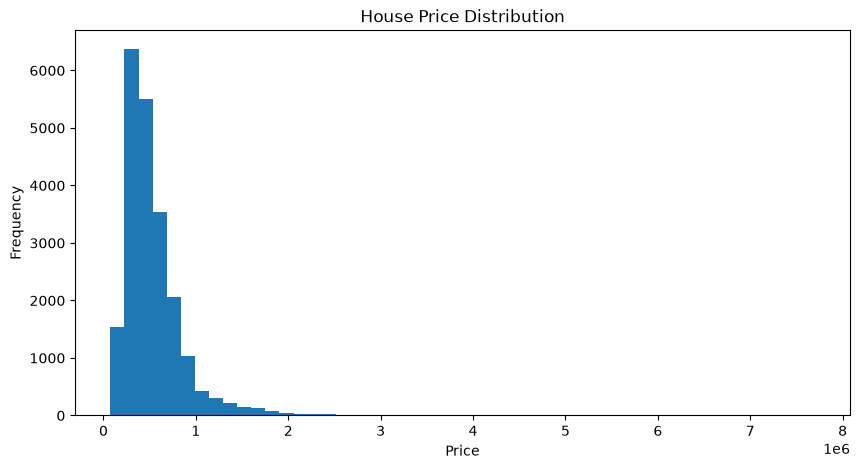

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df["price"], bins=50)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [11]:
df[df["bedrooms"] >= 10][
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "grade"]
].sort_values("bedrooms", ascending=False)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,grade
15870,640000.0,33,1.75,1620,6000,7
8757,520000.0,11,3.00,3000,4960,7
13314,1148000.0,10,5.25,4590,10920,9
15161,650000.0,10,2.00,3610,11914,7
19254,660000.0,10,3.00,2920,3745,7


### Outlier investigation

The dataset contains an extreme observation with 33 bedrooms. 
This value is inconsistent with the rest of the dataset and appears 
to be an anomalous record.

Rather than allowing this observation to disproportionately influence 
the model, it is removed before feature engineering.

In [12]:
clean_df = df[df["bedrooms"] != 33].copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))

Original rows: 21613
Cleaned rows: 21612


In [13]:
data = clean_df.copy()

# Convert date
data["date"] = pd.to_datetime(data["date"])

# 1. Sale year
data["sale_year"] = data["date"].dt.year

# 2. House age at time of sale
data["house_age"] = data["sale_year"] - data["yr_built"]

# 3. Living area relative to lot size
data["living_to_lot_ratio"] = (
    data["sqft_living"] /
    data["sqft_lot"].replace(0, np.nan)
)

# 4. Living space per bedroom
data["living_sqft_per_bedroom"] = (
    data["sqft_living"] /
    data["bedrooms"].replace(0, np.nan)
)

# 5. Years since renovation
# 0 = never renovated
data["years_since_renovation"] = np.where(
    (data["yr_renovated"] == 0) |
    (data["yr_renovated"] > data["sale_year"]),
    0,
    data["sale_year"] - data["yr_renovated"]
)

# 6. Total square footage
data["total_sqft"] = (
    data["sqft_above"] + data["sqft_basement"]
)

# Handle invalid values
data = data.replace([np.inf, -np.inf], np.nan)

# Fill missing values created by division by zero
data["living_to_lot_ratio"] = (
    data["living_to_lot_ratio"]
    .fillna(data["living_to_lot_ratio"].median())
)

data["living_sqft_per_bedroom"] = (
    data["living_sqft_per_bedroom"]
    .fillna(data["living_sqft_per_bedroom"].median())
)

# Remove ID and raw date
data = data.drop(columns=["id", "date"])

print("Features:", data.shape[1])
print(data.columns.tolist())

print("\nMissing values:", data.isnull().sum().sum())

Features: 25
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'house_age', 'living_to_lot_ratio', 'living_sqft_per_bedroom', 'years_since_renovation', 'total_sqft']

Missing values: 0


In [14]:
# Train-test split

X = data.drop(columns=["price"])
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Features:", X.shape[1])
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Features: 24
Training samples: 17289
Testing samples: 4323


In [15]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

print("\nTraining missing values:", X_train.isnull().sum().sum())
print("Testing missing values:", X_test.isnull().sum().sum())

print("\nTarget statistics:")
print(y_train.describe())

print("\nFeature dtypes:")
print(X_train.dtypes)

Training samples: 17289
Testing samples: 4323
Features: 24

Training missing values: 0
Testing missing values: 0

Target statistics:
count    1.728900e+04
mean     5.384116e+05
std      3.618683e+05
min      7.500000e+04
25%      3.210000e+05
50%      4.500000e+05
75%      6.410000e+05
max      7.700000e+06
Name: price, dtype: float64

Feature dtypes:
bedrooms                     int64
bathrooms                  float64
sqft_living                  int64
sqft_lot                     int64
floors                     float64
waterfront                   int64
view                         int64
condition                    int64
grade                        int64
sqft_above                   int64
sqft_basement                int64
yr_built                     int64
yr_renovated                 int64
zipcode                      int64
lat                        float64
long                       float64
sqft_living15                int64
sqft_lot15                   int64
sale_year       

In [16]:
# Baseline Model
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $125,889.71
RMSE: $210,313.81
R²:   0.7053


In [17]:
# Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE:  ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

MAE:  $72,510.14
RMSE: $145,397.13
R²:   0.8591


In [18]:
# CatBoost Model

catboost_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=["zipcode"]
)

CatBoostRegressor(depth=7, iterations=1200, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)

In [19]:
# Evaluate the CatBoost model

catboost_pred = catboost_model.predict(X_test)

catboost_mae = mean_absolute_error(y_test, catboost_pred)
catboost_rmse = np.sqrt(mean_squared_error(y_test, catboost_pred))
catboost_r2 = r2_score(y_test, catboost_pred)

print(f"MAE:  ${catboost_mae:,.2f}")
print(f"RMSE: ${catboost_rmse:,.2f}")
print(f"R²:   {catboost_r2:.4f}")

MAE:  $63,144.44
RMSE: $114,843.87
R²:   0.9121


In [20]:
feature_importance = pd.Series(
    catboost_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

lat                        22.402803
long                       12.560145
grade                      12.482139
sqft_living                12.467985
zipcode                     9.747073
total_sqft                  6.602818
view                        3.557079
sqft_living15               3.383373
waterfront                  3.259349
sqft_above                  2.893501
yr_built                    2.102804
house_age                   1.289933
sqft_lot                    1.240137
bathrooms                   0.988572
sqft_basement               0.906601
living_to_lot_ratio         0.772113
living_sqft_per_bedroom     0.738772
condition                   0.623317
sqft_lot15                  0.543690
sale_year                   0.469987
yr_renovated                0.389420
bedrooms                    0.251266
floors                      0.223540
years_since_renovation      0.103581
dtype: float64

In [21]:
# Save the CatBoost model

model_path = Path("../models/house_price_model.cbm")

catboost_model.save_model(model_path)

print(f"Model saved successfully: {model_path}")

Model saved successfully: ..\models\house_price_model.cbm


In [22]:
print("Final X_train shape:", X_train.shape)
print("\nFinal feature names:")
for feature in X_train.columns:
    print(feature)

Final X_train shape: (17289, 24)

Final feature names:
bedrooms
bathrooms
sqft_living
sqft_lot
floors
waterfront
view
condition
grade
sqft_above
sqft_basement
yr_built
yr_renovated
zipcode
lat
long
sqft_living15
sqft_lot15
sale_year
house_age
living_to_lot_ratio
living_sqft_per_bedroom
years_since_renovation
total_sqft
